## 0. Введение

Этот ноутбук демонстрирует использование `manuscript-ocr` версий >= 0.1.12 в сценарии интеграции со сторонними системами распознавания. В данном примере показано, как заменить стандартный этап распознавания в pipeline на внешнюю модель `taiga75/ru-trocr-1700s` архитектуры TrOCR.

Модель `taiga75/ru-trocr-1700s` опубликована на Hugging Face автором Maria Levchenko и используется здесь как внешний компонент. Она не является частью репозитория `manuscript-ocr`, не входит в поставку проекта и не распространяется вместе с ним. Библиотека `transformers`, необходимая для загрузки и запуска этой модели, также не входит в базовые зависимости проекта и устанавливается отдельно для данного примера.

Минимальные технические требования для запуска примера:

- Python 3.8+
- не менее 16 ГБ оперативной памяти
- доступ в интернет при первом запуске для загрузки весов модели с Hugging Face
- запуск на CPU поддерживается, но может выполняться медленно
- для запуска на GPU рекомендуется NVIDIA GPU с видеопамятью от 12 ГБ

Следует учитывать, что модель TrOCR является ресурсоемкой. На видеокартах с 8 ГБ VRAM успешный запуск примера не гарантируется.

## 1. Установка зависимостей

In [ ]:
%pip install transformers==5.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 90.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
%pip install "manuscript-ocr>=0.1.12"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.2/574.2 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 110.5 MB/s eta 0:00:00


## 2. Определение TrOCRRecognizer

Согласно документации для версии `0.1.12` и выше, распознаватель в `Pipeline` должен реализовать метод `predict`, который принимает объект `Page` и при необходимости исходное изображение, а затем возвращает обновленный объект `Page`.

В данном примере `TrOCRRecognizer` реализует метод:

`predict(self, page: Page, image=None, batch_size=None) -> Page`

Внутри метода из объекта `Page` берутся текстовые области, для них вырезаются фрагменты исходного изображения, затем эти фрагменты передаются в модель `taiga75/ru-trocr-1700s`. Полученный текст записывается обратно в объект `Page`.

In [3]:
from pathlib import Path
from typing import Optional, Union

import numpy as np
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

from manuscript.data import Page
from manuscript.utils import collapse_page_text_spans, crop_axis_aligned, read_image


class TrOCRRecognizer:
    def __init__(
        self,
        model_name: str = "taiga75/ru-trocr-1700s",
        device: Optional[str] = None,
        batch_size: int = 4,
    ):
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.processor = TrOCRProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name).to(self.device).eval()

    @staticmethod
    def _to_pil(img):
        if isinstance(img, Image.Image):
            return img.convert("RGB")

        img = np.asarray(img)
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        if img.ndim == 3 and img.shape[2] == 4:
            img = img[:, :, :3]

        return Image.fromarray(img.astype(np.uint8)).convert("RGB")

    @staticmethod
    def _crop(image, polygon):
        return crop_axis_aligned(image, polygon)

    def predict(
        self,
        page: Page,
        image: Optional[Union[str, Path, np.ndarray, Image.Image]] = None,
        batch_size: Optional[int] = None,
    ) -> Page:
        if image is None:
            return page.model_copy(deep=True)

        image = read_image(image)

        # Схлопываем все text span внутри каждой строки в один общий span
        result_page = collapse_page_text_spans(
            page,
            level="line",
            method="convex_hull",
        )

        spans = []
        crops = []

        for block in result_page.blocks:
            for line in block.lines:
                if not line.text_spans:
                    continue

                span = line.text_spans[0]
                crop = self._crop(image, span.polygon)
                if crop is None or crop.size == 0:
                    continue

                spans.append(span)
                crops.append(self._to_pil(crop))

        if not crops:
            return result_page

        step = batch_size or self.batch_size

        for i in range(0, len(crops), step):
            batch = crops[i:i + step]
            pixel_values = self.processor(images=batch, return_tensors="pt").pixel_values.to(self.device)

            with torch.no_grad():
                tokens = self.model.generate(pixel_values)

            texts = self.processor.batch_decode(tokens, skip_special_tokens=True)

            for span, text in zip(spans[i:i + step], texts):
                span.text = text.strip()
                span.recognition_confidence = 1.0

        return result_page

## 3. Пример использования

Используем встроенный детектор и новый TrOCR распознаватель.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

east_50_g1.onnx: 100%|███████████████████████| 107M/107M [00:02<00:00, 50.6MB/s]


 Downloaded to /root/.manuscript/weights/east_50_g1.onnx
[EAST] Device configuration:
  Requested device: cpu
  Requested providers: ['CPUExecutionProvider']
  Active providers: ['CPUExecutionProvider']
  Running on: CPUExecutionProvider
Распознанный текст:
3,0
их оъ
85.
лями-какъ 1: 21.
Въ исходъ 1865 года, от-
ставному дрителю Трини-
цыну разрѣшено открыть
вка. Красноярскi Ластный
пансинъ,
Вхбытность выг. Красно-
ярскi при ревизш Енисейфы
губернш- Генералъ- Губерна-
торъ Восточной Сибири
нашелъ, что предположен-
ный къ покупнiъ За 30 руб.
домѣ Наслѣдниковъ Мясни
ковыхъ, для мужской Гимна-
3ш- по дорогой цѣнъ и дру-
еимъ причинамъ неѲцетъ
соотъютствовать своему
назначенiю; въ Зеимънѣ таї
коваго, по личному осмотру
нгъ сколькихъ ѕданiй Генералъ
Лейтенантъ Кареаковъ из-
бралъ Каменный 2їтажный
фольъ принадлежащiй кщ
51 52
88.
50 4
86.
печеской женъ Ребиковой.
Велгъфстьи сего, здание это,
вмѣсть съ флигелями,
надворными строенiями
и1833% кваѳр. саженями
Усадеѱной Земли, куплено
на собран

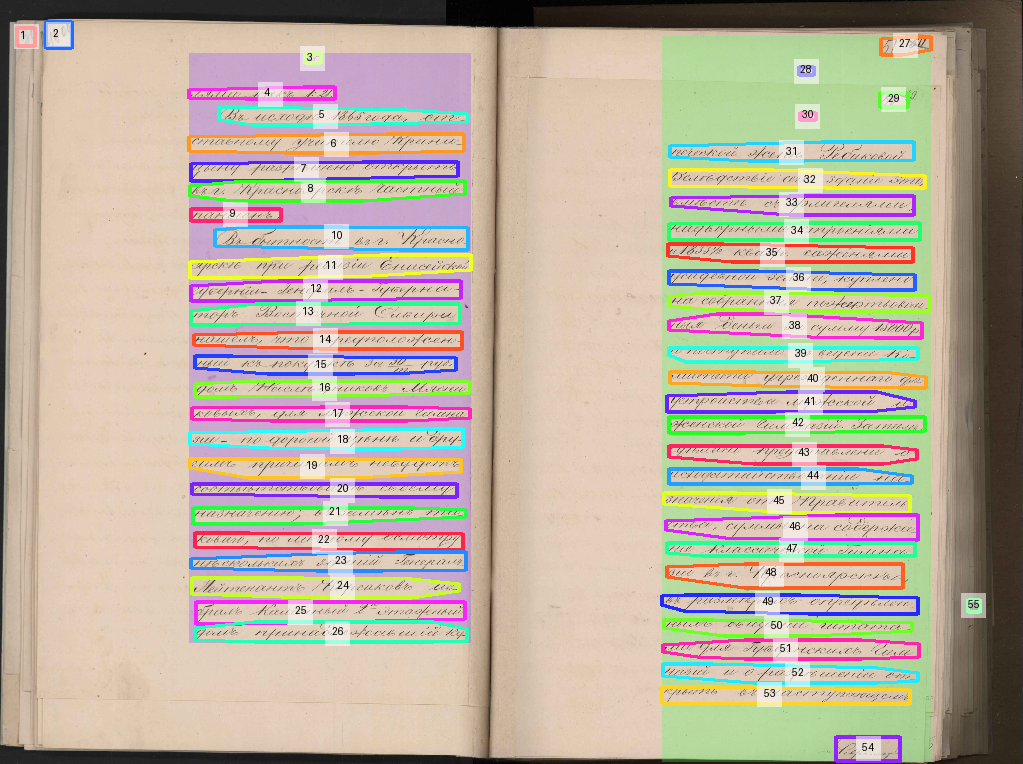

In [4]:
from pathlib import Path
from urllib.request import urlretrieve

from manuscript import Pipeline
from manuscript.utils import visualize_page
from manuscript.detectors import EAST

image_url = "https://raw.githubusercontent.com/konstantinkozhin/manuscript-ocr/main/example/images/img1.jpeg"
image_path = Path("img1.jpeg")

if not image_path.exists():
    urlretrieve(image_url, image_path)

trocr_recognizer = TrOCRRecognizer(
    model_name="taiga75/ru-trocr-1700s",
    batch_size=1,
)

pipeline = Pipeline(
    detector = EAST(),
    recognizer=trocr_recognizer,
)

result = pipeline.predict(str(image_path))
page = result["page"]

print("=" * 50)
print("Распознанный текст:")
print("=" * 50)
print(pipeline.get_text(page))

visualize_page(
    str(image_path),
    page,
    show_lines=False,
    show_numbers=True,
    max_size=1024,
)

Следует учитывать, что качество распознавания в данном примере определяется не встроенными средствами `manuscript-ocr`, а внешней моделью `taiga75/ru-trocr-1700s`, подключенной к `Pipeline`. Соответственно, итоговое качество распознавания зависит прежде всего от выбранной модели TrOCR и ее характеристик, а не от самой библиотеки `manuscript-ocr`.

Таким образом, `manuscript-ocr` может использоваться совместно с другими решениями распознавания без значительных доработок и может быть встроен в интеграционные сценарии с внешними моделями.